## Formatting for Plots

In [5]:
import sys
import pandas as pd
from pathlib import Path
root = Path().resolve()
src_path = root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from analysislib import formatting
from analysislib import graphs
formatting.format_notebook()


from analysislib import sdss
sdss.setup(pd.read_csv("data/SDSS_500k_v7.csv"))

---

## Part 3 — Shape, Size, and Structure

---

<div style="width: 1200px">

In Part 2, we discovered that galaxies split into two distinct colour populations — a blue, star-forming cloud and a red, quenched sequence — with surprisingly few galaxies in between. Colour alone tells us a great deal about a galaxy's evolutionary state. But it raises an immediate question:

**Does a galaxy's *shape* tell the same story as its colour?**

Intuitively, we might expect blue star-forming galaxies to look different from red quenched ones. And indeed they do — spiral galaxies, with their sweeping disc structures and active star-forming arms, tend to be blue; elliptical galaxies, smooth and featureless, tend to be red. But the relationship is not perfect, and the exceptions are often the most scientifically interesting cases.

In this notebook, we move beyond colour and begin measuring **structure** — how spread out the light is, how centrally concentrated it is, and how these properties connect to evolutionary state.

</div>

---

### Galaxy Morphology and the Hubble Tuning Fork

---

<div style="width: 1200px">

Every galaxy has a shape, and that shape is the accumulated record of billions of years of mergers, gas inflows, star formation, and quenching. The systematic classification of galaxy shapes began in the 1920s with Edwin Hubble, who organised the variety of galaxy forms into the **Hubble Tuning Fork** — one of the most iconic diagrams in astronomy.

The diagram arranges galaxies along two axes:

* **Left → right:** from smooth, featureless ellipticals to disc-dominated spirals with open, patchy arms. Moving right, bulges shrink, discs grow, and star formation increases.
* **The fork split:** separates normal spirals (top arm) from barred spirals (bottom arm) — galaxies with a straight stellar bar through the centre from which the arms emerge. About half of all disc galaxies, including the Milky Way, are barred.

The classes are:

| Class | Name | Key features |
|-------|------|--------------|
| E0–E7 | Ellipticals | Smooth, round to elongated, no disc or arms. Old red stars, essentially no star formation |
| S0 | Lenticular | Has a disc but no spiral arms — the bridge between ellipticals and spirals |
| Sa → Sc | Spirals | Disc with arms; bulge shrinks and arms open from Sa to Sc |
| SBa → SBc | Barred spirals | Like Sa–Sc but with a central stellar bar |

> **A common misconception:** Hubble called ellipticals "early-type" and spirals "late-type", implying galaxies evolve left to right. We now know this is wrong — if anything, mergers turn spirals *into* ellipticals, not the reverse. The "early/late" labels have unfortunately stuck in the literature.

The interactive diagram below maps the full tuning fork. Click any class to see how it connects to the SDSS measurements we use throughout this project.

</div>

In [6]:
from IPython.display import HTML

HTML(graphs.hubble_fork())

<div style="width: 1200px">

Notice how the SDSS measurements shown for each type — $g-r$ colour, concentration $C$, and `fracDeV_r` — shift systematically as you move across the fork. These are exactly the columns we use in the plots below, so the diagram acts as a key to everything that follows.

One more morphological type worth knowing: **irregular galaxies** (Irr) don't fit the tuning fork at all. They are chaotic, asymmetric, and intensely star-forming — often disturbed by tidal interactions with a neighbour. The Large and Small Magellanic Clouds are classic examples. At higher redshifts, irregular morphologies become far more common, reflecting the more violent, merger-rich early universe.

<br>

Credit: NASA, ESA, Göran Nilsson

</div>

---

### The Petrosian Radius — "How Spread Out is the Light?"

---

<div style="width: 1200px">

Measuring the size of a galaxy is harder than it sounds. Unlike a ball with a clear edge, galaxies fade gradually into the background — there is no sharp boundary where a galaxy ends and empty space begins. We need a robust, distance-independent way to define "how big" a galaxy is.

The solution the SDSS uses is called the **Petrosian radius**, and the idea is elegant. Rather than asking "where does the galaxy end?", we ask:

> *At what radius does the galaxy's surface brightness drop to a fixed fraction of the average brightness inside that radius?*

The Petrosian radius $r_P$ is defined as the radius at which the local surface brightness equals 20% of the mean enclosed surface brightness. Think of it as the point where the galaxy starts to "fade into the background" in a well-defined, reproducible way. Crucially, it is **independent of distance** — making it ideal for comparing galaxy sizes across our sample.

Two derived quantities also appear in the data:

* **`petroR50`** — the radius enclosing 50% of the total Petrosian flux (the half-light radius)
* **`petroR90`** — the radius enclosing 90% of the total Petrosian flux

The ratio between these two is the key to our next measurement.

</div>

---

### The Concentration Index and Sérsic Profile

---

<div style="width: 1200px">

Knowing how big a galaxy is tells us one thing. Knowing *where* the light is distributed tells us something much richer about its structure.

The **concentration index** $C$ captures this in a single number:

$$C = 5 \times \log_{10}\left(\frac{r_{90}}{r_{50}}\right)$$

A galaxy with light tightly packed into the centre has a large $r_{90}/r_{50}$ ratio — you need to go much further out to capture the outer 40%. A disc galaxy with smoothly spread light has a smaller ratio. In practice: $C \gtrsim 3.0$ → elliptical; $C \approx 2.3$–$3.0$ → lenticular; $C \lesssim 2.3$ → spiral.

This connects directly to the **Sérsic index** $n$, which describes the *shape* of the brightness profile — how quickly light fades outward from the centre:

$$I(r) \propto \exp\left[-b_n\left(\left(\frac{r}{r_e}\right)^{1/n} - 1\right)\right]$$

* **$n = 1$** (exponential) → spiral disc: light fades smoothly and steadily
* **$n = 4$** (de Vaucouleurs) → elliptical: bright compact core with slowly fading wings

The SDSS column `fracDeV_r` is our Sérsic proxy — it records what fraction of the light is better described by the $n=4$ de Vaucouleurs profile vs the $n=1$ exponential. Values near `1.0` mean elliptical-like; near `0.0` mean disc-like.

</div>

---

### Setting Up

---

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from IPython.display import display, HTML

display(HTML("""
<style>
  .widget-label { color: #cccccc !important; font-family: monospace !important; }
  .jupyter-widgets { background: transparent !important; }
</style>
"""))

galaxies = sdss._galaxies()

galaxies["g_r"] = galaxies["g"] - galaxies["r"]
galaxies["C"]   = 5 * np.log10(galaxies["petroR90_r"] / galaxies["petroR50_r"])

galaxies = galaxies[
    (galaxies["g_r"] > -0.2) & (galaxies["g_r"] < 1.4) &
    (galaxies["C"]   >  1.5) & (galaxies["C"]   < 4.5) &
    (galaxies["petroRad_r"] < 200)
].copy()

gal_lowz = galaxies[galaxies["redshift"] < 0.05].copy()
gal_lowz["colour_class"] = pd.cut(
    gal_lowz["g_r"],
    bins=[-np.inf, 0.58, 0.76, np.inf],
    labels=["Blue Cloud", "Green Valley", "Red Sequence"]
)
blue  = gal_lowz[gal_lowz["colour_class"] == "Blue Cloud"]
green = gal_lowz[gal_lowz["colour_class"] == "Green Valley"]
red   = gal_lowz[gal_lowz["colour_class"] == "Red Sequence"]

print(f"Full sample:      {len(galaxies):,}")
print(f"Low-z (z<0.05):   {len(gal_lowz):,}")
print(f"  Blue Cloud:     {len(blue):,}")
print(f"  Green Valley:   {len(green):,}")
print(f"  Red Sequence:   {len(red):,}")

Full sample:      115,767
Low-z (z<0.05):   9,280
  Blue Cloud:     3,830
  Green Valley:   2,034
  Red Sequence:   3,416


/usr/local/python/3.12.1/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


---

### Plot 1 — Concentration Index by Colour Class

---

<div style="width: 1200px">

If the tuning fork picture is correct — ellipticals red, spirals blue — then blue and red galaxies should have systematically different concentration indices in our data. Let's check whether the numbers bear this out.

</div>

FileNotFoundError: [Errno 2] No such file or directory: 'figures/concentration_by_colour.png'

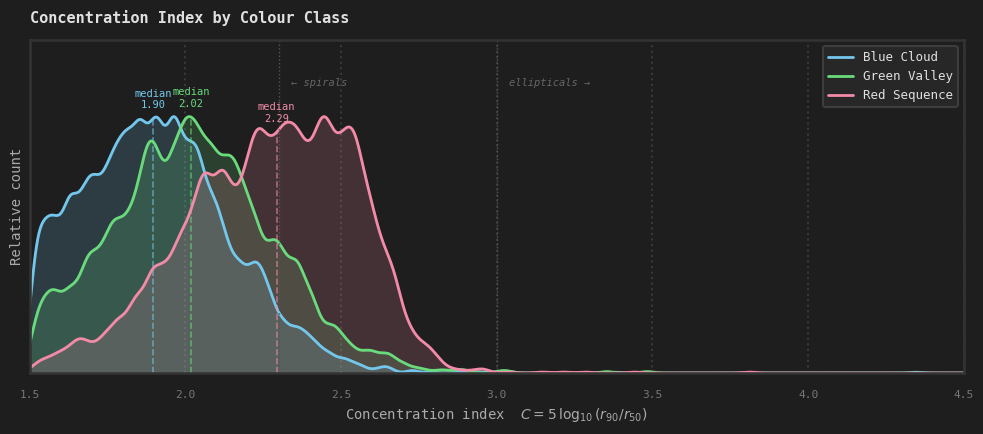

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")
x_range = np.linspace(1.5, 4.5, 800)

for pop, color, label in [
    (blue,  "#74c7ec", "Blue Cloud"),
    (green, "#69db7c", "Green Valley"),
    (red,   "#f38ba8", "Red Sequence"),
]:
    vals = pop["C"].dropna().values
    if len(vals) < 50: continue
    kde = gaussian_kde(vals, bw_method=0.08)
    k = kde(x_range) / kde(x_range).max()
    ax.fill_between(x_range, 0, k, color=color, alpha=0.18)
    ax.plot(x_range, k, lw=2, color=color, label=label)
    med = np.median(vals)
    ax.vlines(med, 0, kde([med])[0]/kde(x_range).max(),
              color=color, lw=1.2, linestyle="--", alpha=0.6)
    ax.text(med, kde([med])[0]/kde(x_range).max() + 0.04,
            f"median\n{med:.2f}", color=color, fontsize=7.5, ha="center")

for x_ref, lbl in [(2.3, "← spirals"), (3.0, "ellipticals →")]:
    ax.axvline(x_ref, color="#555555", lw=1, linestyle=":")
    ax.text(x_ref + 0.04, 1.12, lbl, color="#666666", fontsize=7.5, style="italic")

ax.set_xlim(1.5, 4.5)
ax.set_ylim(0, 1.3)
ax.set_yticks([])
ax.set_xlabel(r"Concentration index  $C = 5\,\log_{10}(r_{90}/r_{50})$",
              color="#aaaaaa", fontsize=10)
ax.set_ylabel("Relative count", color="#aaaaaa", fontsize=10)
ax.set_title("Concentration Index by Colour Class",
             color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, linestyle=":", alpha=0.12, color="#ffffff")
ax.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="#e0e0e0", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor("#333333")
plt.tight_layout()
plt.savefig("figures/concentration_by_colour.png", dpi=150,
            bbox_inches="tight", facecolor="#1e1e1e")
plt.show()

<div style="width: 1200px">

The separation matches the tuning fork prediction exactly. Blue Cloud galaxies peak at lower $C$ — disc-dominated spirals with spread-out light. Red Sequence galaxies peak higher — bulge-dominated ellipticals with concentrated light. Green Valley galaxies span both, consistent with a population caught mid-transformation: some may have already built a dominant bulge while still retaining some disc structure.

The dashed reference lines at $C = 2.3$ and $C = 3.0$ mark the conventional spiral/lenticular/elliptical boundaries — and the three distributions straddle them in exactly the order the tuning fork predicts.

</div>

---

### Plot 2 — The Four Galaxy Families

---

<div style="width: 1200px">

The concentration distribution tells us colour and morphology are correlated — but how tight is the relationship, and what do the outliers look like? Plotting concentration against $g-r$ colour directly reveals four naturally defined families, each telling a different physical story:

| | Blue ($g-r < 0.58$) | Red ($g-r > 0.76$) |
|---|---|---|
| **High C** | Compact star-formers — rare, possibly post-merger starbursts | **Ellipticals** — bulge-dominated, quenched |
| **Low C** | **Spirals** — disc-dominated, actively star-forming | Passive discs (S0/lenticular) — quenched but disc survived |

The off-diagonal families are the most scientifically interesting — they show that colour and structure can decouple, hinting at different quenching pathways.

</div>

In [10]:
from PIL import Image

def pick_representative(df, gr_lo, gr_hi, c_lo, c_hi):
    subset = df[
        (df["g_r"] >= gr_lo) & (df["g_r"] < gr_hi) &
        (df["C"]   >= c_lo)  & (df["C"]   < c_hi)  &
        (df["petroRad_r"] > 8)
    ].copy()
    gr_mid = (gr_lo + gr_hi) / 2
    c_mid  = (c_lo  + c_hi)  / 2
    subset["dist"] = (
        ((subset["g_r"] - gr_mid) / (gr_hi - gr_lo))**2 +
        ((subset["C"]   - c_mid)  / (c_hi  - c_lo))**2
    )
    return subset.nsmallest(1, "dist")

quadrants = [
    dict(name="Compact star-former",  img_path="images/compact_blue.jpg",
         gr_lo=0.1,  gr_hi=0.55, c_lo=2.4, c_hi=3.5,
         color="#74c7ec", subtitle="Blue + concentrated\n(rare — possible starburst)"),
    dict(name="Elliptical galaxy",    img_path="images/elliptical.jpg",
         gr_lo=0.76, gr_hi=1.3,  c_lo=2.4, c_hi=3.5,
         color="#f38ba8", subtitle="Red + concentrated\n(quenched, bulge-dominated)"),
    dict(name="Spiral galaxy",        img_path="images/spiral.jpg",
         gr_lo=0.1,  gr_hi=0.55, c_lo=1.5, c_hi=2.4,
         color="#74c7ec", subtitle="Blue + diffuse\n(disc-dominated, star-forming)"),
    dict(name="Passive disc (S0)",    img_path="images/passive_disc.jpg",
         gr_lo=0.76, gr_hi=1.3,  c_lo=1.5, c_hi=2.4,
         color="#fab387", subtitle="Red + diffuse\n(quenched but disc survived)"),
]

for q in quadrants:
    q["img"] = Image.open(q["img_path"])
    rep = pick_representative(gal_lowz, q["gr_lo"], q["gr_hi"], q["c_lo"], q["c_hi"])
    q["galaxy"] = rep.iloc[0] if len(rep) > 0 else None
    if q["galaxy"] is not None:
        print(f"{q['name']}: g-r={q['galaxy']['g_r']:.2f}, C={q['galaxy']['C']:.2f}")

# --- scatter data ---
sample = gal_lowz.sample(min(30000, len(gal_lowz)), random_state=42)
sx, sy = sample["g_r"].values, sample["C"].values
dens = gaussian_kde(np.vstack([sx, sy]))(np.vstack([sx, sy]))
idx  = dens.argsort()
sx, sy, dens = sx[idx], sy[idx], dens[idx]
ld = np.log1p(dens); ld = (ld - ld.min()) / (ld.max() - ld.min())

# --- figure ---
fig = plt.figure(figsize=(13, 8), facecolor="#1e1e1e")
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        width_ratios=[1, 1, 1.5], hspace=0.42, wspace=0.22)
axes_img   = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]),
              fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]
ax_scatter = fig.add_subplot(gs[:, 2])

for ax, q in zip(axes_img, quadrants):
    ax.set_facecolor("#0d0d0d")
    ax.imshow(q["img"])
    ax.set_title(q["name"], color=q["color"], fontsize=9, fontweight="bold", pad=5)
    ax.text(0.5, -0.14, q["subtitle"], transform=ax.transAxes,
            color="#aaaaaa", fontsize=7.5, ha="center", style="italic")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(q["color"]); spine.set_linewidth(1.5)

ax_scatter.set_facecolor("#1e1e1e")
ax_scatter.scatter(sx, sy, c=ld, s=1.5, alpha=0.6, cmap="inferno", rasterized=True)

# mark representatives
for q in quadrants:
    if q["galaxy"] is None: continue
    ax_scatter.scatter(q["galaxy"]["g_r"], q["galaxy"]["C"],
                       s=140, color=q["color"], zorder=6,
                       edgecolors="white", linewidths=0.8, marker="*")

ax_scatter.axvspan(0.55, 0.76, color="#69db7c", alpha=0.05)
ax_scatter.text(0.655, 3.35, "Green\nValley", color="#69db7c",
                fontsize=7, ha="center", style="italic")

gr_bins = np.linspace(-0.1, 1.3, 25)
gr_mids = 0.5*(gr_bins[:-1]+gr_bins[1:])
medians = [np.median(gal_lowz[(gal_lowz["g_r"]>=lo)&(gal_lowz["g_r"]<hi)]["C"])
           if len(gal_lowz[(gal_lowz["g_r"]>=lo)&(gal_lowz["g_r"]<hi)])>20 else np.nan
           for lo,hi in zip(gr_bins[:-1],gr_bins[1:])]
ax_scatter.plot(gr_mids, medians, color="#ffffff", lw=1.8, alpha=0.45,
                linestyle="--", label="Median C per colour bin")
ax_scatter.legend(facecolor="#2a2a2a", edgecolor="#444444",
                  labelcolor="#e0e0e0", fontsize=7)

ax_scatter.set_xlim(-0.15, 1.35)
ax_scatter.set_ylim(1.0, 3.6)
ax_scatter.set_xlabel("g − r colour index", color="#aaaaaa", fontsize=9)
ax_scatter.set_ylabel(r"Concentration index $C$", color="#aaaaaa", fontsize=9)
ax_scatter.set_title("Where each family sits\nin colour-concentration space",
                     color="#e0e0e0", fontsize=9, pad=8)
ax_scatter.tick_params(colors="#777777", labelsize=7)
ax_scatter.grid(True, linestyle=":", alpha=0.10, color="#ffffff")
for spine in ax_scatter.spines.values(): spine.set_edgecolor("#333333")
ax_scatter.text(1.33, 1.05, "z < 0.05", color="#555555", fontsize=7,
                ha="right", style="italic")

fig.suptitle("The Four Galaxy Families — real SDSS images, real positions in the data",
             color="#e0e0e0", fontsize=11, fontweight="bold", y=1.01)
plt.savefig("figures/four_galaxy_families.png", dpi=150,
            bbox_inches="tight", facecolor="#1e1e1e")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'images/compact_blue.jpg'

<div style="width: 1200px">

Each star marker on the scatter shows the exact position of the galaxy pictured in the corresponding image panel. The two dominant populations — spirals (bottom-left) and ellipticals/quenched systems (bottom-right, slightly higher $C$) — are the densest regions of the scatter. The off-diagonal families are sparse but real:

* **Compact star-formers (top-left):** High concentration but blue — possibly triggered by mergers that simultaneously compressed the stellar mass and ignited a burst of star formation.
* **Passive discs (bottom-right, low C):** Red but diffuse — quenched without destroying the disc, suggesting a gentle internal process rather than a violent merger.

The dashed median trend line shows the modest but real increase in $C$ with redness — the tuning fork colour-morphology relationship is present in the data, even if the scatter is large.

</div>

---

### Plot 3 — Petrosian Radius vs Redshift

---

<div style="width: 1200px">

Plotting apparent size against redshift does two things at once: it reveals the **survey geometry** (how the observable population changes with distance) and a real **physical size trend** (do red and blue galaxies have different physical extents?). The median trend lines per colour class make the size difference quantitative.

</div>

FileNotFoundError: [Errno 2] No such file or directory: 'figures/petrorad_vs_redshift.png'

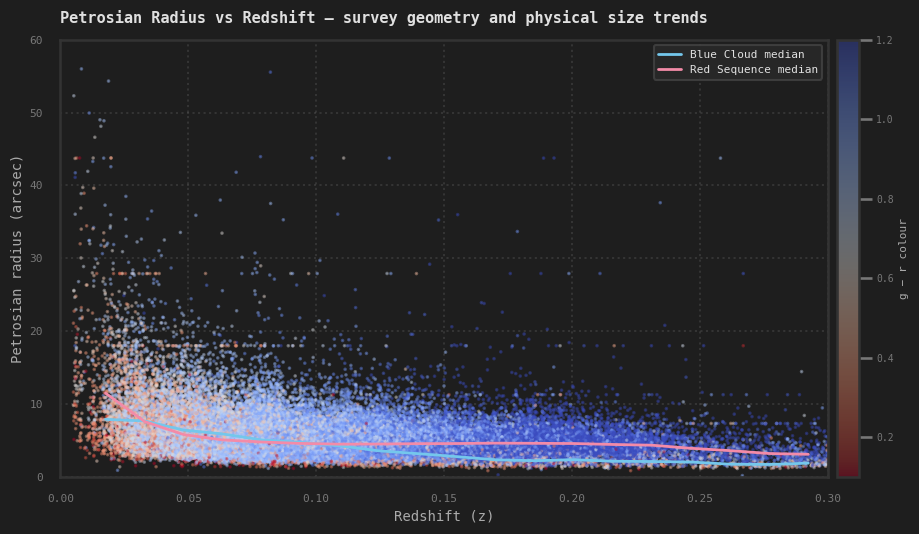

In [11]:
sample_z = galaxies[
    (galaxies["redshift"] > 0.005) & (galaxies["redshift"] < 0.30) &
    (galaxies["petroRad_r"] < 60)
].sample(min(60000, len(galaxies)), random_state=42)

gr_clip = sample_z["g_r"].clip(-0.1, 1.3)

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")
sc = ax.scatter(sample_z["redshift"], sample_z["petroRad_r"],
                c=gr_clip, cmap="coolwarm_r", vmin=0.1, vmax=1.2,
                s=1.2, alpha=0.4, rasterized=True)

z_bins = np.linspace(0.01, 0.30, 20)
z_mids = 0.5*(z_bins[:-1]+z_bins[1:])
for subset, color, label in [
    (galaxies[(galaxies["redshift"]<0.30)&(galaxies["g_r"]<0.58)], "#74c7ec", "Blue Cloud median"),
    (galaxies[(galaxies["redshift"]<0.30)&(galaxies["g_r"]>0.76)], "#f38ba8", "Red Sequence median"),
]:
    meds = [np.median(subset[(subset["redshift"]>=lo)&(subset["redshift"]<hi)&
                              (subset["petroRad_r"]<60)]["petroRad_r"])
            if len(subset[(subset["redshift"]>=lo)&(subset["redshift"]<hi)])>10 else np.nan
            for lo,hi in zip(z_bins[:-1],z_bins[1:])]
    ax.plot(z_mids, meds, color=color, lw=2, label=label, zorder=5)

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label("g − r colour", color="#aaaaaa", fontsize=8)
cbar.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777777", fontsize=7)
cbar.outline.set_edgecolor("#333333")

ax.set_xlabel("Redshift (z)", color="#aaaaaa", fontsize=10)
ax.set_ylabel("Petrosian radius (arcsec)", color="#aaaaaa", fontsize=10)
ax.set_title("Petrosian Radius vs Redshift — survey geometry and physical size trends",
             color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.set_xlim(0, 0.30); ax.set_ylim(0, 60)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, linestyle=":", alpha=0.10, color="#ffffff")
ax.legend(facecolor="#2a2a2a", edgecolor="#444444",
          labelcolor="#e0e0e0", fontsize=8, loc="upper right")
for spine in ax.spines.values(): spine.set_edgecolor("#333333")
plt.tight_layout()
plt.savefig("figures/petrorad_vs_redshift.png", dpi=150,
            bbox_inches="tight", facecolor="#1e1e1e")
plt.show()

<div style="width: 1200px">

Three features to unpack:

**The upper envelope drops with redshift** — at low $z$ we see a wide range of apparent sizes; at higher $z$ only compact or intrinsically large galaxies remain detectable. This is the flux limit at work.

**The lower envelope stays roughly flat** — the smallest detectable sizes are set by the telescope's seeing limit (~1–2 arcseconds), not by the galaxy population itself.

**Red galaxies are systematically smaller than blue ones** at the same redshift. This is real physics: elliptical galaxies have concentrated their stellar mass into smaller volumes than spiral galaxies of similar luminosity — exactly what the higher concentration index $C$ tells us in a different way.

</div>

---

### Bonus Plot — Profile Shape vs Concentration

---

<div style="width: 1200px">

`fracDeV_r` and $C$ measure galaxy structure in completely different ways — one from the *shape* of the brightness profile, the other from the ratio of two aperture radii. If both are capturing the same physical reality, they should agree. Let's check.

</div>

In [ ]:
sample_fd = gal_lowz[
    (gal_lowz["fracDeV_r"] >= 0) & (gal_lowz["fracDeV_r"] <= 1)
].sample(min(25000, len(gal_lowz)), random_state=42)

x = sample_fd["fracDeV_r"].values
y = sample_fd["C"].values
c = sample_fd["g_r"].clip(0.0, 1.2).values
idx = np.argsort(c)
x, y, c = x[idx], y[idx], c[idx]

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")
sc = ax.scatter(x, y, c=c, cmap="coolwarm_r", vmin=0.1, vmax=1.1,
                s=2, alpha=0.5, rasterized=True)

cp = dict(fontsize=8.5, bbox=dict(boxstyle="round,pad=0.35",
                                   fc="#1e1e1e", ec="#444444", alpha=0.8))
ax.text(0.05, 4.2, "Disc profile + compact",    color="#cba6f7", ha="left",  **cp)
ax.text(0.92, 4.2, "Bulge profile + compact\n(ellipticals)", color="#f38ba8", ha="center", **cp)
ax.text(0.05, 1.65, "Disc profile + diffuse\n(spirals)",     color="#74c7ec", ha="left",  **cp)
ax.text(0.92, 1.65, "Bulge profile + diffuse",  color="#fab387", ha="center", **cp)

ax.axvline(0.5, color="#555555", lw=1, linestyle=":")
ax.axhline(2.75, color="#555555", lw=1, linestyle=":")

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label("g − r colour (blue → red)", color="#aaaaaa", fontsize=8)
cbar.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777777", fontsize=7)
cbar.outline.set_edgecolor("#333333")

ax.set_xlabel("de Vaucouleurs fraction  (0 = pure disc,  1 = pure bulge)",
              color="#aaaaaa", fontsize=10)
ax.set_ylabel(r"Concentration index $C$", color="#aaaaaa", fontsize=10)
ax.set_title("Profile Shape vs Concentration — two independent morphology measures agree",
             color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.set_xlim(-0.05, 1.05); ax.set_ylim(1.5, 4.5)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, linestyle=":", alpha=0.10, color="#ffffff")
for spine in ax.spines.values(): spine.set_edgecolor("#333333")
ax.text(1.03, 1.55, "z < 0.05 sample",
        color="#555555", fontsize=7, ha="right", style="italic")
plt.tight_layout()
plt.savefig("figures/fracdev_vs_concentration.png", dpi=150,
            bbox_inches="tight", facecolor="#1e1e1e")
plt.show()

<div style="width: 1200px">

The two measurements agree remarkably well — galaxies with high `fracDeV_r` (bulge-like profiles) also tend to have high $C$ and be red, while those with low `fracDeV_r` (disc-like) tend to have low $C$ and be blue. Two completely different computational methods, the same physical picture.

Notice also that `fracDeV_r` shows a **bimodal distribution** — galaxies cluster near `0` or near `1`, with relatively few in between. This morphological bimodality mirrors the colour bimodality from Part 2, and reinforces the key finding: galaxy evolution is not a smooth continuum but a process that pushes objects toward one of two distinct states.

</div>

---

### What We've Learned

---

<div style="width: 1200px">

Structure and colour tell a consistent story — but with important nuance.

* **The Hubble Tuning Fork organises galaxy morphology** into a sequence from ellipticals (red, concentrated, quenched) to spirals (blue, diffuse, star-forming) — and our SDSS measurements reproduce this gradient quantitatively.

* **Colour and morphology are correlated but not identical.** The off-diagonal families — passive discs and compact star-formers — show that quenching and structural transformation are not always the same event, and may follow different timescales.

* **The Petrosian radius encodes real physics.** Red galaxies are physically more compact than blue ones at the same redshift — a direct consequence of their different formation histories.

* **Two independent morphology measures agree.** The concentration index $C$ and the de Vaucouleurs fraction `fracDeV_r` are computed in completely different ways but point to the same physical picture, giving us confidence that the signal is real.

In the next notebook, we move from structure to **distance** — using redshift and luminosity to place our galaxies in space and time, and beginning to trace how galaxy properties have evolved across cosmic history.

</div>